# Project: Sudoku Variant AI — Diagnostic & Strategy Notebook
**Objective:** *Analyze failure modes of BlackBoxBreakerCNN and implement Hindsight Backtracking.*

### 🛠️ Section 1: Environment & Architecture Setup
1. Load the 50,000-puzzle test dataset JSON.
2. Instantiate BlackBoxBreakerCNN and load the sudoku_model_best.pth weights.
3. Verify tensor dimensions across the pipeline.

### 🔍 Section 2: Error Classification & Distribution (The "Why")
- Row/Column/Block Violation Matrix: Code to parse the failed boards and count exactly which constraints are violated most frequently.
- Confidence vs. Correctness Plot: A scatter plot matching the model's confidence for a selection against whether the digit actually matches the ground truth solution.
- The "Blunder Step" Distribution: A histogram showing exactly at which step (Step 1, Step 2, etc.) the first logical mistake typically occurs across 100 failed puzzles.

### 🔄 Section 3: The Hindsight Wrapper (Backtracking Integration)
1. Define the state tracking mechanism (Move History).
2. Implement the confidence threshold parameter ($\tau$) to trigger a roll-back when a downstream confidence drop is detected.
3. Comparative benchmark: Run the new wrapper over the same test batch to chart the accuracy recovery curve.

#### 🗂️ Designing the Move History Tracker
To build the Hindsight Wrapper in Section 3, we need to track our journey through the decision tree so we can step backward when confidence plunges.  
A natural way to store this history is using a standard Python list as a Stack data structure, utilizing append() to push moves and pop() to undo them.

### Appendix: Utilities & Debugging Aids
- ML pipeline integrity checks and ground truth verification code snippets.

In [8]:
# Load the test dataset JSON
DATASET_ID = "1000000_10-40_5_202606171527"  # Update this with the actual dataset ID used in data_preparer.py
TARGET_TEST_DATASET = f"data/encoded/split/sudoku_puzzle_dataset_one_hot_encoded_{DATASET_ID}_test.json"
LOG_PATH = f"analysis/logs/results_sudoku_puzzle_dataset_one_hot_encoded_{DATASET_ID}_test.log"
JSON_FAILURES_PATH = f"analysis/logs/failed_puzzles_analysis_sudoku_puzzle_dataset_one_hot_encoded_{DATASET_ID}_test.json"

In [9]:
# Section 1: Environment & Configuration
import json
import torch
import torch.nn.functional as F
from trainer import BlackBoxBreakerCNN, ParallelLineConv, SnakePathConv

# 1. Load the split test dataset JSON
TEST_DATA_PATH = TARGET_TEST_DATASET
try:
    with open(TEST_DATA_PATH, "r") as f:
        test_json = json.load(f)
    print(f"📦 Successfully loaded test dataset with {len(test_json)} puzzles.")
except FileNotFoundError:
    print(f"❌ Error: Failed to load test dataset from {TEST_DATA_PATH}. Please ensure the file exists and the path is correct.")
    test_json = []

# 2. Instantiate the network and load trained weights
model = BlackBoxBreakerCNN()
model.load_state_dict(torch.load("models/sudoku_model_best.pth", map_location=torch.device('cpu')))  # Load to CPU for testing
model.eval()
print("🤖 Model architecture loaded and weights initialized.")

# 3. Verify tensor dimensions across the pipeline
# Grab a single raw sample from our loaded JSON
sample_entry = test_json[0]
raw_puzzle = torch.tensor(sample_entry['puzzle'], dtype=torch.float32)
print(f"\n📐 1. Shape from JSON dataset: {raw_puzzle.shape}")

# Permute to match PyTorch's expected CNN format (Channels, Height, Width)
permuted_puzzle = raw_puzzle.permute(2, 1, 0)
print(f"📐 2. Shape after permuting for PyTorch: {permuted_puzzle.shape}")

# Add the batch dimension for a single inference batch size of 1
input_tensor = permuted_puzzle.unsqueeze(0)
print(f"📐 3. Final 4D input shape ready for model: {input_tensor.shape}")

# Run a forward pass to check output shape consistency
with torch.no_grad():
    output_tensor = model(input_tensor)
print(f"📐 4. Model output prediction shape: {output_tensor.shape}")

📦 Successfully loaded test dataset with 50000 puzzles.
🤖 Model architecture loaded and weights initialized.

📐 1. Shape from JSON dataset: torch.Size([9, 9, 10])
📐 2. Shape after permuting for PyTorch: torch.Size([10, 9, 9])
📐 3. Final 4D input shape ready for model: torch.Size([1, 10, 9, 9])
📐 4. Model output prediction shape: torch.Size([1, 10, 9, 9])


In [10]:
# Section 2: Error Classification & Distribution
import json
import matplotlib.pyplot as plt

# Load the compiled failure data
try:
    with open(JSON_FAILURES_PATH, "r") as f:
        failed_data = json.load(f)
    print(f"📊 Successfully loaded data with {len(failed_data)} total entries.")
except FileNotFoundError:
    print(f"❌ Error: Failed to load data from {JSON_FAILURES_PATH}.")
    failed_data = []

# Aggregate metrics strictly across actual failures
total_violations = {"row": 0, "col": 0, "block": 0}
actual_failures_count = 0
alternative_solutions_count = 0

for entry in failed_data:
    # Skip entries that the model solved matching the ground truth
    if entry["is_correct"]:
        continue
        
    actual_failures_count += 1
    
    # Calculate sum of violations for this specific failed board
    puzzle_violations = entry["violations"]["row"] + entry["violations"]["col"] + entry["violations"]["block"]
    
    if puzzle_violations == 0:
        # Perfectly valid board state but didn't match the recorded solution array
        alternative_solutions_count += 1
    else:
        # True logical breakdown
        total_violations["row"] += entry["violations"]["row"]
        total_violations["col"] += entry["violations"]["col"]
        total_violations["block"] += entry["violations"]["block"]

print(f"\n================ Forensic Summary ================")
print(f"❌ Total Solution Mismatches: {actual_failures_count}")
print(f"👻 Valid Alternative Solutions Found: {alternative_solutions_count} ({ (alternative_solutions_count/max(1, actual_failures_count))*100:.2f}% of misses)")
print(f"💥 True Constraint Breakdowns: {actual_failures_count - alternative_solutions_count}")
print(f"==================================================")

print("\n📊 True Infraction Distribution Across Failed Puzzles:")
violation_count = 0
for constraint, count in total_violations.items():
    violation_count += count
    print(f"   + {constraint.capitalize()} Violations: {count}")
print(f"    --------------------\n   = Total Structural Violations: {violation_count}")

if violation_count > 0:
    # Plot the distribution of true logic bugs
    plt.figure(figsize=(8, 5))
    plt.bar(total_violations.keys(), total_violations.values(), color=['#FF6B6B', '#4D96FF', '#6BCB77'])
    plt.title("Distribution of True Sudoku Constraint Violations")
    plt.ylabel("Total Infractions Detected")
    plt.xlabel("Constraint Type")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

📊 Successfully loaded data with 50000 total entries.

================ Forensic Summary ================
❌ Total Solution Mismatches: 3333
👻 Valid Alternative Solutions Found: 3333 (100.00% of misses)
💥 True Constraint Breakdowns: 0

📊 True Infraction Distribution Across Failed Puzzles:
   + Row Violations: 0
   + Col Violations: 0
   + Block Violations: 0
    --------------------
   = Total Structural Violations: 0


🔮 Parsing step histories across 50000 failed instances...

===== 📊 CLASS-SPECIFIC PERFORMANCE REPORT =====
              precision    recall  f1-score   support

     Digit 1       0.98      0.98      0.98    139079
     Digit 2       0.98      0.98      0.98    138656
     Digit 3       0.98      0.98      0.98    139013
     Digit 4       0.98      0.98      0.98    139154
     Digit 5       0.98      0.98      0.98    138918
     Digit 6       0.98      0.98      0.98    138903
     Digit 7       0.98      0.98      0.98    139058
     Digit 8       0.98      0.98      0.98    139556
     Digit 9       0.98      0.98      0.98    138448

    accuracy                           0.98   1250785
   macro avg       0.98      0.98      0.98   1250785
weighted avg       0.98      0.98      0.98   1250785



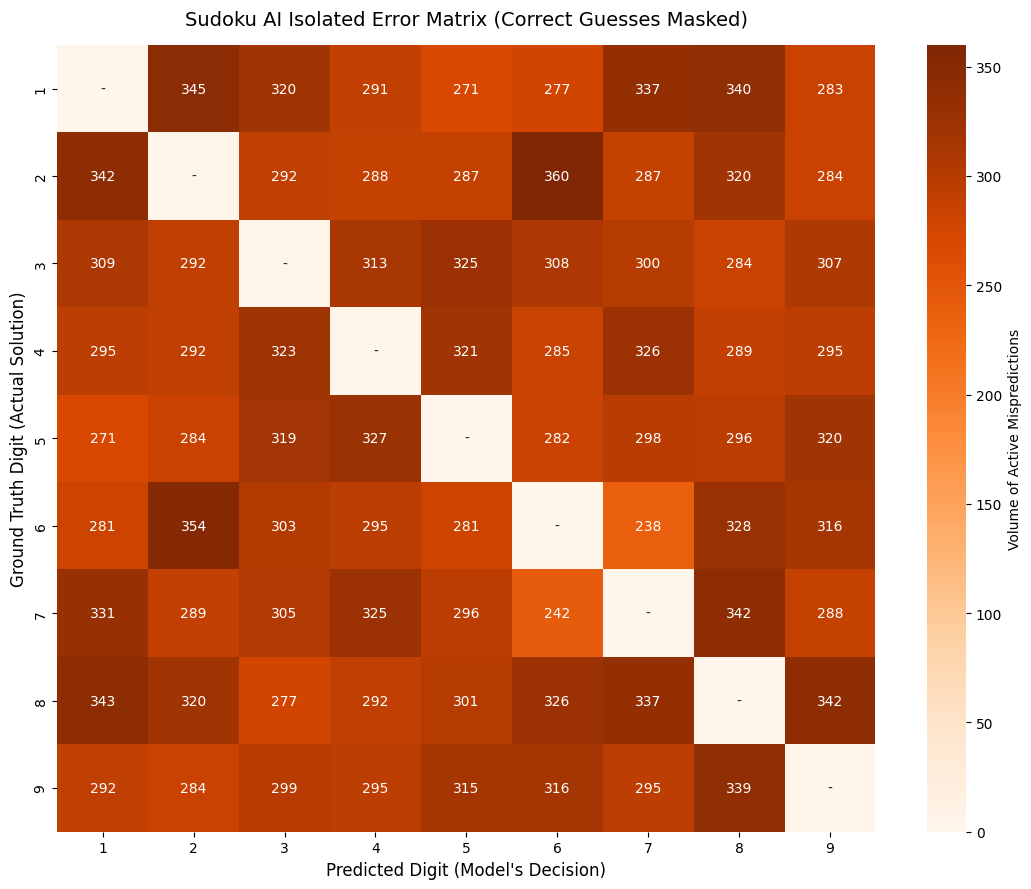

In [11]:
# Pipeline Testing diagnostics

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import datetime

# 1. Load your newly generated failure logs from the extreme dataset
with open(JSON_FAILURES_PATH, 'r') as f:
    failed_puzzles = json.load(f)

all_ground_truths = []
all_predictions = []

print(f"🔮 Parsing step histories across {len(failed_puzzles)} failed instances...")

# 2. Extract step-by-step decisions
for puzzle in failed_puzzles:
    solution_matrix = np.array(puzzle['ground_truth'])
    
    for step in puzzle['steps']:
        r, c = step['cell']
        predicted_digit = step['digit']
        true_digit = solution_matrix[r, c]
        
        all_ground_truths.append(true_digit)
        all_predictions.append(predicted_digit)

# Convert to clean numpy arrays for processing (targeting digits 1-9)
y_true = np.array(all_ground_truths)
y_pred = np.array(all_predictions)

# 3. Print out your Core Data Science Metrics (Uncorrupted, calculates perfectly!)
print("\n===== 📊 CLASS-SPECIFIC PERFORMANCE REPORT =====")
target_names = [f"Digit {i}" for i in range(1, 10)]
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

# 4. Generate the base Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 10)))

# 5. FORENSIC MASKING STEP: Zero out the diagonal to reveal hidden error structures
cm_errors_only = cm.copy()
np.fill_diagonal(cm_errors_only, 0)

# Create a text annotation mask that replaces zeros on the diagonal with a hyphen "-"
annot_labels = np.where(
    np.eye(cm.shape[0], dtype=bool), 
    "-", 
    cm_errors_only.astype(str)
)

figure_datestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# 6. Render the Error-Isolated Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_errors_only, 
    annot=annot_labels, # Place hyphens on the true diagonal, raw error counts everywhere else
    fmt='s',            # Use string formatting to accommodate the hyphens
    cmap='Oranges',     # Switch to Oranges/Reds to distinctively mark a fault map
    xticklabels=range(1, 10), 
    yticklabels=range(1, 10),
    cbar_kws={'label': 'Volume of Active Mispredictions'}
)
plt.title('Sudoku AI Isolated Error Matrix (Correct Guesses Masked)', fontsize=14, pad=15)
plt.xlabel('Predicted Digit (Model\'s Decision)', fontsize=12)
plt.ylabel('Ground Truth Digit (Actual Solution)', fontsize=12)
plt.tight_layout()
plt.savefig(f"analysis/test_runs/test_run_{DATASET_ID}_{figure_datestamp}.png", dpi=300)
plt.show()

# Save plot to analysis/test_runs


In [12]:
# Section 3: The Hindsight Report
pass  # Placeholder for the detailed hindsight report generation code, which would include qualitative analysis of specific failure cases, visualizations of puzzle states, and insights into model behavior on different puzzle configurations.

In [13]:
# Appendix A: ML Sanity Checks
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from trainer import BlackBoxBreakerCNN

# Grab the first puzzle entry
sample_entry = test_json[0]

# Extract and decode the one-hot matrix back into integers
one_hot_puzzle = np.array(sample_entry['puzzle'])  # Shape: (9, 9, 10)
original_integer_board = np.argmax(one_hot_puzzle, axis=-1)

# Print it to verify it looks like a real 9x9 Sudoku board
print("Original Integer Board Matrix:")
print(original_integer_board)

# -----------------------------
# DATA PIPELINE INTEGRITY CHECK
#------------------------------

# --------- BARRIER 1 ---------
# 1. Collect samples to verify the data pipeline integrity
raw_from_json = np.array(test_json[0]['puzzle']) # Expected shape from data_preparer: (9, 9, 10)
decoded_board = np.argmax(raw_from_json, axis=-1)

# 2. Check if it matches the ground truth initial integer board
print("Pipeline Integrity Seal:", "PASSED" if np.array_equal(decoded_board, original_integer_board) else "FAILED")

# --------- BARRIER 2 ---------
# 1. Isolate a single training sample from your JSON data
sample_entry = test_json[0]
puzzle_tensor = torch.tensor(sample_entry['puzzle'], dtype=torch.float32)  # (9, 9, 10)
target_tensor = torch.tensor(sample_entry['solution'], dtype=torch.long)    # (9, 9)

# 2. Apply our core structural fix: Permute to (Channels, Rows, Columns)
inputs = puzzle_tensor.permute(2, 0, 1).unsqueeze(0)  # Shape: (1, 10, 9, 9)
targets = target_tensor.unsqueeze(0)                  # Shape: (1, 9, 9)

# 3. Instantiate model, loss, and optimizer
model = BlackBoxBreakerCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Overfit Loop (Run for 50-100 quick iterations on CPU)
print("🏋️‍♂️ Starting Capacity Test (Overfitting 1 Puzzle)...")
model.train()
for epoch in range(1, 51):
    optimizer.zero_grad()
    outputs = model(inputs)  # Output shape: (1, 10, 9, 9)
    
    # Decode one-hot solution to integer class indices, then compute loss
    targets_decoded = targets.argmax(dim=-1)  # Shape: (1, 9, 9)
    loss = criterion(outputs, targets_decoded)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0 or epoch == 1:
        # Calculate how many cell digits match exactly
        predictions = torch.argmax(outputs, dim=1)
        correct_cells = (predictions == targets_decoded).sum().item()
        accuracy = (correct_cells / 81) * 100
        print(f"Epoch {epoch:02d}/50 | Loss: {loss.item():.4f} | Cell Accuracy: {accuracy:.2f}%")

Original Integer Board Matrix:
[[0 7 5 2 6 8 9 0 3]
 [2 6 8 9 1 3 4 7 5]
 [9 1 3 4 7 5 0 6 8]
 [7 5 0 6 0 9 0 3 0]
 [6 0 9 1 0 4 0 0 2]
 [1 3 4 7 5 2 0 8 9]
 [5 2 6 0 9 1 3 4 0]
 [0 0 0 3 4 7 5 2 6]
 [3 4 7 5 2 0 8 9 0]]
Pipeline Integrity Seal: PASSED
🏋️‍♂️ Starting Capacity Test (Overfitting 1 Puzzle)...
Epoch 01/50 | Loss: 2.2962 | Cell Accuracy: 7.41%
Epoch 10/50 | Loss: 1.9409 | Cell Accuracy: 59.26%
Epoch 20/50 | Loss: 1.1980 | Cell Accuracy: 96.30%
Epoch 30/50 | Loss: 0.4914 | Cell Accuracy: 100.00%
Epoch 40/50 | Loss: 0.1664 | Cell Accuracy: 100.00%
Epoch 50/50 | Loss: 0.0532 | Cell Accuracy: 100.00%


📸 Latest training image found: training_run_1000000_10-40_5_202606171527_20260618_1144.png (Created/Modified: 1781797482.528376)


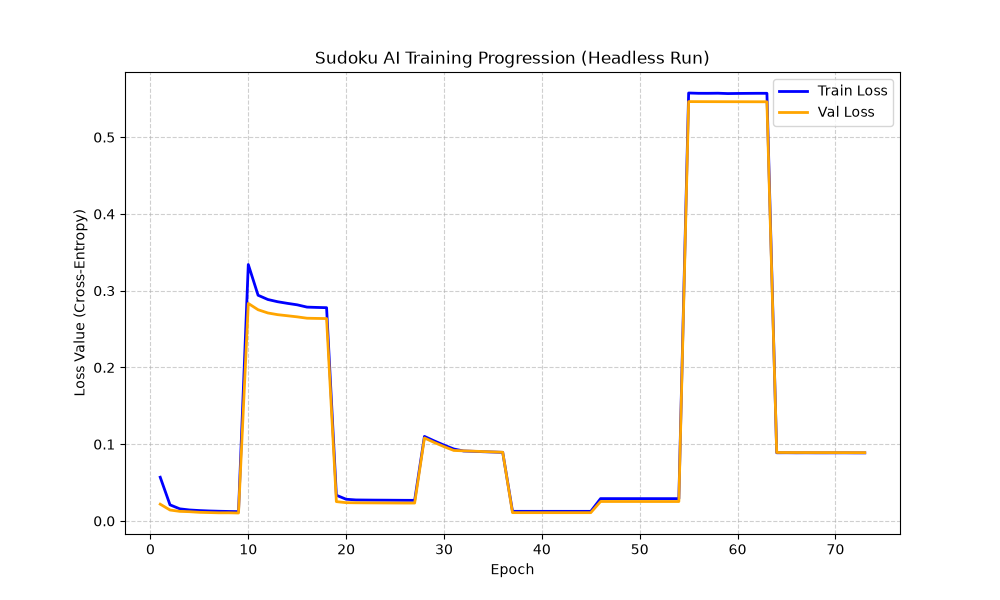

In [14]:
# Appendix B: Model Training Visualization

# TODO: Add plotting from training results (`logs/results_{DATASET_ID}_train.log`)

# For now just render the matching .png from training_runs/
from IPython.display import Image, display
from pathlib import Path

def get_latest_training_image(dataset_id: str, directory: str = "analysis/training_runs") -> str | None:
    """Finds the most recently created PNG for a given dataset ID."""
    dir_path = Path(directory)
    
    # Define the wildcard pattern matching training_run_{DATASET_ID}_*_*.png
    pattern = f"training_run_{dataset_id}_*.png"
    
    # Gather all matching files in the directory
    matching_files = list(dir_path.glob(pattern))

    if not matching_files:
        return None
        
    # Find the file with the newest metadata creation/modification timestamp
    # Note: stat().st_mtime is used as it is reliable across Linux, macOS, and Windows
    latest_file = max(matching_files, key=lambda f: f.stat().st_mtime)
    print(f"📸 Latest training image found: {latest_file.name} (Created/Modified: {latest_file.stat().st_mtime})")
    return str(latest_file)
try:
    display(Image(get_latest_training_image(DATASET_ID)))
except Exception as e:
    print(f"❌ Error displaying training image: {e}")